# Citi Bike 2025 Analytics Notebook

## Section 1: Project Overview

This notebook walks through SQL analyses for the 2025 NYC Citi Bike trip dataset. It uses the local PostgreSQL database built by the ingestion pipeline and focuses on clear product questions.


## Section 2: Dataset Description

The source data comes from the official 2025 Citi Bike monthly trip archives. Raw ZIP files are downloaded locally, extracted to CSV, normalized with DuckDB, written to Parquet, and then loaded into PostgreSQL for analytics.

The public 2025 feed does not include a persistent `user_id`, so active-user metrics use a rider proxy built from `member_casual`, `rideable_type`, and the station pair. That proxy is useful for directional engagement analysis, but it is not a true rider identity and should not be interpreted as one.

Weekly active-user outputs can also be awkward at calendar boundaries because ISO weeks can span year edges. Distinct rider-proxy counts are also recalculated independently for each time grain, so weekly and monthly values should be interpreted separately rather than rolled up into each other. For that reason, this notebook emphasizes monthly active users as the cleaner headline trend, while the full SQL file still includes daily and weekly proxy queries.


## Section 3: Data Processing

The pipeline is intentionally simple and local-first:

1. Download Citi Bike ZIP archives into `data/raw/`
2. Extract CSV files into `data/extracted/`
3. Read and normalize the CSV files with DuckDB
4. Write curated Parquet files into `data/parquet/`
5. Load cleaned `stations` and `trips` tables into PostgreSQL

The curated `trips` schema includes a derived `started_at_est` column so local-time analysis is part of the dataset itself. The notebook queries also compute local time inline where it keeps the SQL easier to read and reason about.


In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import matplotlib.pyplot as plt
import psycopg2

DB_CONFIG = {
    'host': os.getenv('PGHOST', 'localhost'),
    'port': os.getenv('PGPORT', '5432'),
    'dbname': os.getenv('PGDATABASE', 'citibike'),
    'user': os.getenv('PGUSER', 'citibike'),
    'password': os.getenv('PGPASSWORD', 'citibike'),
}


def run_query(query):
    with psycopg2.connect(**DB_CONFIG) as conn:
        with conn.cursor() as cur:
            cur.execute(query)
            columns = [desc[0] for desc in cur.description]
            rows = cur.fetchall()
    return [dict(zip(columns, row)) for row in rows]


def explain_query(query):
    with psycopg2.connect(**DB_CONFIG) as conn:
        with conn.cursor() as cur:
            cur.execute(f"EXPLAIN ANALYZE {query}")
            return [row[0] for row in cur.fetchall()]


def show_explain(title, query):
    print(title)
    print('-' * len(title))
    for line in explain_query(query):
        print(line)
    print()


plt.style.use('ggplot')


## Section 4: Key Metrics

### Monthly Active Users (Proxy)

This query measures monthly active riders using the documented rider proxy because the dataset does not expose a persistent rider identifier. The goal is to show broad engagement seasonality across the 2025 year rather than claim exact unique-rider counts.


In [2]:
monthly_active_users_query = """
WITH rider_day_activity AS (
    SELECT
        (started_at AT TIME ZONE 'America/New_York')::date AS activity_day,
        MD5(
            CONCAT_WS(
                '|',
                COALESCE(member_casual, 'unknown'),
                COALESCE(rideable_type, 'unknown'),
                COALESCE(start_station_id, 'unknown'),
                COALESCE(end_station_id, 'unknown')
            )
        ) AS rider_proxy_id
    FROM trips
    WHERE started_at AT TIME ZONE 'America/New_York' >= TIMESTAMP '2025-01-01 00:00:00'
      AND started_at AT TIME ZONE 'America/New_York' < TIMESTAMP '2026-01-01 00:00:00'
    GROUP BY 1, 2
)
SELECT
    DATE_TRUNC('month', activity_day)::date AS activity_month,
    COUNT(DISTINCT rider_proxy_id) AS monthly_active_users_proxy
FROM rider_day_activity
GROUP BY 1
ORDER BY 1
"""

monthly_active_users_results = run_query(monthly_active_users_query)
monthly_active_users_results


[{'activity_month': datetime.date(2025, 1, 1),
  'monthly_active_users_proxy': 599737},
 {'activity_month': datetime.date(2025, 2, 1),
  'monthly_active_users_proxy': 606779},
 {'activity_month': datetime.date(2025, 3, 1),
  'monthly_active_users_proxy': 896932},
 {'activity_month': datetime.date(2025, 4, 1),
  'monthly_active_users_proxy': 1030233},
 {'activity_month': datetime.date(2025, 5, 1),
  'monthly_active_users_proxy': 1195701},
 {'activity_month': datetime.date(2025, 6, 1),
  'monthly_active_users_proxy': 1261552},
 {'activity_month': datetime.date(2025, 7, 1),
  'monthly_active_users_proxy': 1287563},
 {'activity_month': datetime.date(2025, 8, 1),
  'monthly_active_users_proxy': 1344534},
 {'activity_month': datetime.date(2025, 9, 1),
  'monthly_active_users_proxy': 1309303},
 {'activity_month': datetime.date(2025, 10, 1),
  'monthly_active_users_proxy': 1169232},
 {'activity_month': datetime.date(2025, 11, 1),
  'monthly_active_users_proxy': 920398},
 {'activity_month': dat

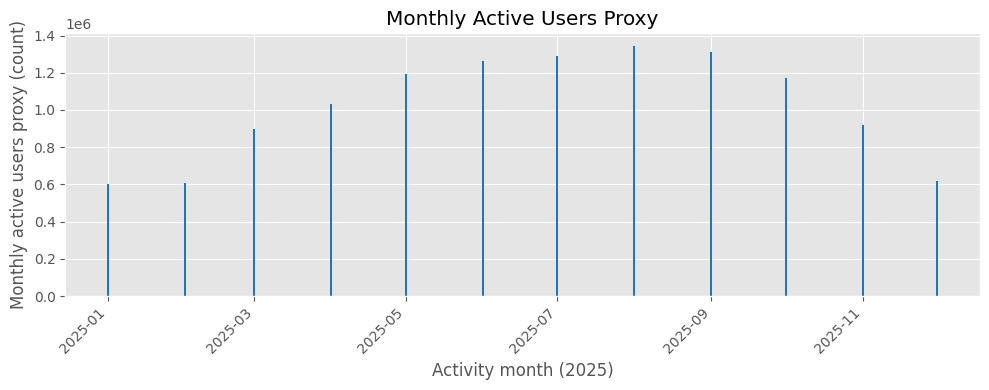

In [3]:
months = [row['activity_month'] for row in monthly_active_users_results]
values = [row['monthly_active_users_proxy'] for row in monthly_active_users_results]

plt.figure(figsize=(10, 4))
plt.bar(months, values, color='#1f77b4')
plt.title('Monthly Active Users Proxy')
plt.xlabel('Activity month (2025)')
plt.ylabel('Monthly active users proxy (count)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The monthly active-user proxy rises from roughly 600 thousand riders in January to a late-summer peak of about 1.34 million in August, then cools through November and December. That shape is consistent with strong weather-driven seasonality and shows why monthly aggregation is a good first lens for the 2025 network.


### Query Performance Checks

These `EXPLAIN ANALYZE` examples show how the project handles performance in a practical way: indexed PostgreSQL tables, local-time staging logic, and reused rider-proxy activity for repeated active-user metrics in the full SQL script.

On this dataset, the peak-hours query finished in about 18.8 seconds and used a `Parallel Index Only Scan` on `idx_trips_started_at`, which is a good sign that the time index is helping the year filter. The expensive part was the grouping step after timezone conversion: PostgreSQL still had to sort tens of millions of rows, and the `external merge` lines show that sort spilled to disk for each worker.

The top-start-stations query finished in about 20.1 seconds, but the plan shows a different shape: PostgreSQL used a `Parallel Seq Scan` on `trips` plus a hash join and aggregate, because the station IDs are being normalized inside the query before grouping. In practice, that means the index helps most with time-filtered queries, while station-heavy analytics benefit more from staging, normalization, and reuse of preprocessed results than from a simple index lookup alone.

In [4]:
peak_hours_explain = """
WITH base AS (
    SELECT
        started_at AT TIME ZONE 'America/New_York' AS started_at_est
    FROM trips
    WHERE started_at AT TIME ZONE 'America/New_York' >= TIMESTAMP '2025-01-01 00:00:00'
      AND started_at AT TIME ZONE 'America/New_York' < TIMESTAMP '2026-01-01 00:00:00'
)
SELECT
    EXTRACT(HOUR FROM started_at_est) AS trip_hour,
    COUNT(*) AS trip_count
FROM base
GROUP BY trip_hour
ORDER BY trip_hour
"""

top_start_stations_explain = """
WITH normalized_trips AS (
    SELECT
        CASE
            WHEN t.start_station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM t.start_station_id))
            ELSE t.start_station_id
        END AS station_id,
        t.start_station_name
    FROM trips t
    WHERE t.start_station_id IS NOT NULL
),
normalized_stations AS (
    SELECT
        CASE
            WHEN s.station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM s.station_id))
            ELSE s.station_id
        END AS station_id,
        MAX(s.station_name) AS station_name
    FROM stations s
    GROUP BY 1
)
SELECT
    t.station_id,
    MAX(COALESCE(s.station_name, t.start_station_name)) AS station_name,
    COUNT(*) AS trip_count
FROM normalized_trips t
LEFT JOIN normalized_stations s
    ON t.station_id = s.station_id
GROUP BY t.station_id
ORDER BY trip_count DESC
LIMIT 10
"""

show_explain('Peak Hours Query Plan', peak_hours_explain)
show_explain('Top Start Stations Query Plan', top_start_stations_explain)


Peak Hours Query Plan
---------------------


Finalize GroupAggregate  (cost=1256879.62..1285418.13 rows=228805 width=40) (actual time=17494.748..18753.909 rows=24 loops=1)
  Group Key: (EXTRACT(hour FROM (trips.started_at AT TIME ZONE 'America/New_York'::text)))
  ->  Gather Merge  (cost=1256879.62..1281032.71 rows=190670 width=40) (actual time=17482.487..18753.826 rows=72 loops=1)
        Workers Planned: 2
        Workers Launched: 2
        ->  Partial GroupAggregate  (cost=1255879.59..1258024.63 rows=95335 width=40) (actual time=16198.856..17455.165 rows=24 loops=3)
              Group Key: (EXTRACT(hour FROM (trips.started_at AT TIME ZONE 'America/New_York'::text)))
              ->  Sort  (cost=1255879.59..1256117.93 rows=95335 width=32) (actual time=16182.724..16917.124 rows=15253778 loops=3)
                    Sort Key: (EXTRACT(hour FROM (trips.started_at AT TIME ZONE 'America/New_York'::text)))
                    Sort Method: external merge  Disk: 178384kB
                    Worker 0:  Sort Method: external merge  Di

Limit  (cost=4864545.21..4864545.24 rows=10 width=72) (actual time=20016.158..20031.936 rows=10 loops=1)
  ->  Sort  (cost=4864545.21..4864550.33 rows=2047 width=72) (actual time=19890.566..19906.342 rows=10 loops=1)
        Sort Key: (count(*)) DESC
        Sort Method: top-N heapsort  Memory: 26kB
        ->  Finalize GroupAggregate  (cost=4863956.79..4864500.98 rows=2047 width=72) (actual time=19888.920..19906.133 rows=2249 loops=1)
              Group Key: (CASE WHEN (t.start_station_id ~ '^[0-9]+(\.[0-9]+)?$'::text) THEN TRIM(TRAILING '.'::text FROM TRIM(TRAILING '0'::text FROM t.start_station_id)) ELSE t.start_station_id END)
              ->  Gather Merge  (cost=4863956.79..4864434.45 rows=4094 width=72) (actual time=19888.873..19905.420 rows=6744 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    ->  Sort  (cost=4862956.76..4862961.88 rows=2047 width=72) (actual time=19877.777..19877.898 rows=2248 loops=3)
               

### Peak Hours and Duration Percentiles

This pair of queries asks two product questions: when does demand concentrate during the local day, and how long does a typical ride last after filtering out invalid and extreme-duration trips.


In [5]:
peak_hours_query = """
WITH base AS (
    SELECT
        started_at AT TIME ZONE 'America/New_York' AS started_at_est
    FROM trips
    WHERE started_at AT TIME ZONE 'America/New_York' >= TIMESTAMP '2025-01-01 00:00:00'
      AND started_at AT TIME ZONE 'America/New_York' < TIMESTAMP '2026-01-01 00:00:00'
)
SELECT
    EXTRACT(HOUR FROM started_at_est) AS trip_hour,
    LPAD(CAST(EXTRACT(HOUR FROM started_at_est) AS VARCHAR), 2, '0') || ':00' AS trip_hour_label,
    COUNT(*) AS trip_count
FROM base
GROUP BY 1, 2
ORDER BY 1
"""

duration_percentiles_query = """
SELECT
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY trip_duration_seconds) / 60.0 AS p50_minutes,
    PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY trip_duration_seconds) / 60.0 AS p90_minutes,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY trip_duration_seconds) / 60.0 AS p95_minutes
FROM trips
WHERE trip_duration_seconds IS NOT NULL
  AND trip_duration_seconds > 0
  AND trip_duration_seconds < 86400
"""

peak_hours_results = run_query(peak_hours_query)
duration_percentiles_results = run_query(duration_percentiles_query)
peak_hours_results, duration_percentiles_results


([{'trip_hour': Decimal('0'),
   'trip_hour_label': '00:00',
   'trip_count': 642360},
  {'trip_hour': Decimal('1'),
   'trip_hour_label': '01:00',
   'trip_count': 389703},
  {'trip_hour': Decimal('2'),
   'trip_hour_label': '02:00',
   'trip_count': 249252},
  {'trip_hour': Decimal('3'),
   'trip_hour_label': '03:00',
   'trip_count': 163545},
  {'trip_hour': Decimal('4'),
   'trip_hour_label': '04:00',
   'trip_count': 155026},
  {'trip_hour': Decimal('5'),
   'trip_hour_label': '05:00',
   'trip_count': 340511},
  {'trip_hour': Decimal('6'),
   'trip_hour_label': '06:00',
   'trip_count': 922492},
  {'trip_hour': Decimal('7'),
   'trip_hour_label': '07:00',
   'trip_count': 1886892},
  {'trip_hour': Decimal('8'),
   'trip_hour_label': '08:00',
   'trip_count': 2902632},
  {'trip_hour': Decimal('9'),
   'trip_hour_label': '09:00',
   'trip_count': 2414216},
  {'trip_hour': Decimal('10'),
   'trip_hour_label': '10:00',
   'trip_count': 2037857},
  {'trip_hour': Decimal('11'),
   'tri

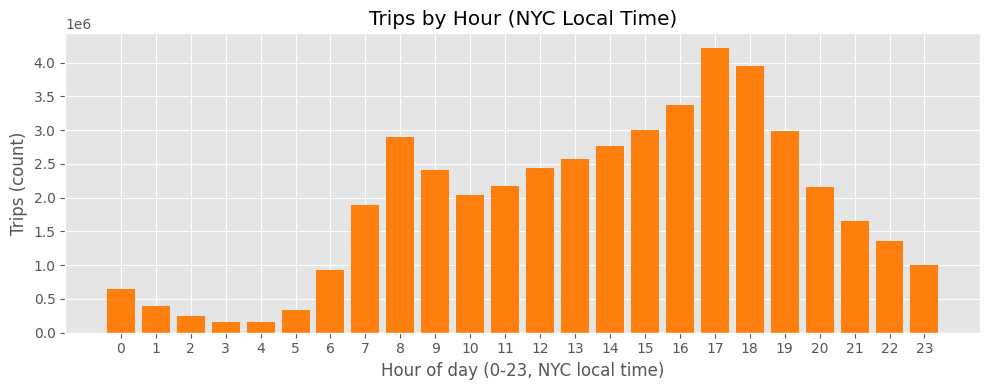

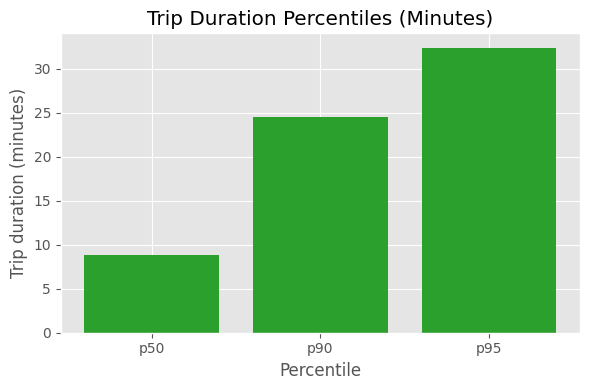

In [6]:
hours = [int(row['trip_hour']) for row in peak_hours_results]
counts = [row['trip_count'] for row in peak_hours_results]

plt.figure(figsize=(10, 4))
plt.bar(hours, counts, color='#ff7f0e')
plt.title('Trips by Hour (NYC Local Time)')
plt.xlabel('Hour of day (0-23, NYC local time)')
plt.ylabel('Trips (count)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

percentile_labels = ['p50', 'p90', 'p95']
percentile_values = [
    duration_percentiles_results[0]['p50_minutes'],
    duration_percentiles_results[0]['p90_minutes'],
    duration_percentiles_results[0]['p95_minutes'],
]

plt.figure(figsize=(6, 4))
plt.bar(percentile_labels, percentile_values, color='#2ca02c')
plt.title('Trip Duration Percentiles (Minutes)')
plt.xlabel('Percentile')
plt.ylabel('Trip duration (minutes)')
plt.tight_layout()
plt.show()


The hourly distribution peaks in the late afternoon, with the strongest volume at 17:00 and the next-highest hour at 18:00 New York time. The duration percentiles stay compact relative to the trip volume: the median ride is just under nine minutes, while the 90th and 95th percentiles show a longer but still bounded tail once obviously invalid and extreme rides are filtered out.


## Section 5: Station Analysis

These queries look at where rides start and where bikes tend to accumulate or drain over time. They group by normalized `station_id` values so formatting variants do not split the same physical station across multiple rows, while still displaying the most readable available station name in the final output.


In [7]:
top_start_stations_query = """
WITH normalized_trips AS (
    SELECT
        CASE
            WHEN t.start_station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM t.start_station_id))
            ELSE t.start_station_id
        END AS station_id,
        t.start_station_name
    FROM trips t
    WHERE t.start_station_id IS NOT NULL
),
normalized_stations AS (
    SELECT
        CASE
            WHEN s.station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM s.station_id))
            ELSE s.station_id
        END AS station_id,
        MAX(s.station_name) AS station_name
    FROM stations s
    GROUP BY 1
)
SELECT
    t.station_id,
    MAX(COALESCE(s.station_name, t.start_station_name)) AS station_name,
    COUNT(*) AS trip_count
FROM normalized_trips t
LEFT JOIN normalized_stations s
    ON t.station_id = s.station_id
GROUP BY t.station_id
ORDER BY trip_count DESC
LIMIT 10
"""

station_imbalance_query = """
WITH normalized_trips AS (
    SELECT
        CASE
            WHEN t.start_station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM t.start_station_id))
            ELSE t.start_station_id
        END AS normalized_start_station_id,
        CASE
            WHEN t.end_station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM t.end_station_id))
            ELSE t.end_station_id
        END AS normalized_end_station_id,
        t.start_station_name,
        t.end_station_name
    FROM trips t
),
normalized_stations AS (
    SELECT
        CASE
            WHEN s.station_id ~ '^[0-9]+(\.[0-9]+)?$' THEN
                TRIM(TRAILING '.' FROM TRIM(TRAILING '0' FROM s.station_id))
            ELSE s.station_id
        END AS station_id,
        MAX(s.station_name) AS station_name
    FROM stations s
    GROUP BY 1
),
inflow AS (
    SELECT
        t.normalized_end_station_id AS station_id,
        MAX(COALESCE(s.station_name, t.end_station_name)) AS station_name,
        COUNT(*) AS inbound_trips
    FROM normalized_trips t
    LEFT JOIN normalized_stations s
        ON t.normalized_end_station_id = s.station_id
    WHERE t.normalized_end_station_id IS NOT NULL
    GROUP BY 1
),
outflow AS (
    SELECT
        t.normalized_start_station_id AS station_id,
        MAX(COALESCE(s.station_name, t.start_station_name)) AS station_name,
        COUNT(*) AS outbound_trips
    FROM normalized_trips t
    LEFT JOIN normalized_stations s
        ON t.normalized_start_station_id = s.station_id
    WHERE t.normalized_start_station_id IS NOT NULL
    GROUP BY 1
)
SELECT
    COALESCE(i.station_id, o.station_id) AS station_id,
    COALESCE(i.station_name, o.station_name) AS station_name,
    COALESCE(i.inbound_trips, 0) AS inbound_trips,
    COALESCE(o.outbound_trips, 0) AS outbound_trips,
    COALESCE(i.inbound_trips, 0) - COALESCE(o.outbound_trips, 0) AS net_inflow
FROM inflow i
FULL OUTER JOIN outflow o
    ON i.station_id = o.station_id
ORDER BY ABS(COALESCE(i.inbound_trips, 0) - COALESCE(o.outbound_trips, 0)) DESC
LIMIT 15
"""

top_start_stations_results = run_query(top_start_stations_query)
station_imbalance_results = run_query(station_imbalance_query)
top_start_stations_results, station_imbalance_results


([{'station_id': '6140.05',
   'station_name': 'W 21 St & 6 Ave',
   'trip_count': 166769},
  {'station_id': '6233.04',
   'station_name': 'Pier 61 at Chelsea Piers',
   'trip_count': 150528},
  {'station_id': '5788.13',
   'station_name': 'Lafayette St & E 8 St',
   'trip_count': 146959},
  {'station_id': '5329.03',
   'station_name': 'West St & Chambers St',
   'trip_count': 140184},
  {'station_id': '6331.01',
   'station_name': 'W 31 St & 7 Ave',
   'trip_count': 138331},
  {'station_id': '6492.08',
   'station_name': '9 Ave & W 33 St',
   'trip_count': 134851},
  {'station_id': '5905.12',
   'station_name': 'Broadway & E 14 St',
   'trip_count': 133953},
  {'station_id': '5905.14',
   'station_name': 'University Pl & E 14 St',
   'trip_count': 130043},
  {'station_id': '6948.1',
   'station_name': 'Broadway & W 58 St',
   'trip_count': 129718},
  {'station_id': '6726.01',
   'station_name': '11 Ave & W 41 St',
   'trip_count': 129501}],
 [{'station_id': '6847.02',
   'station_name

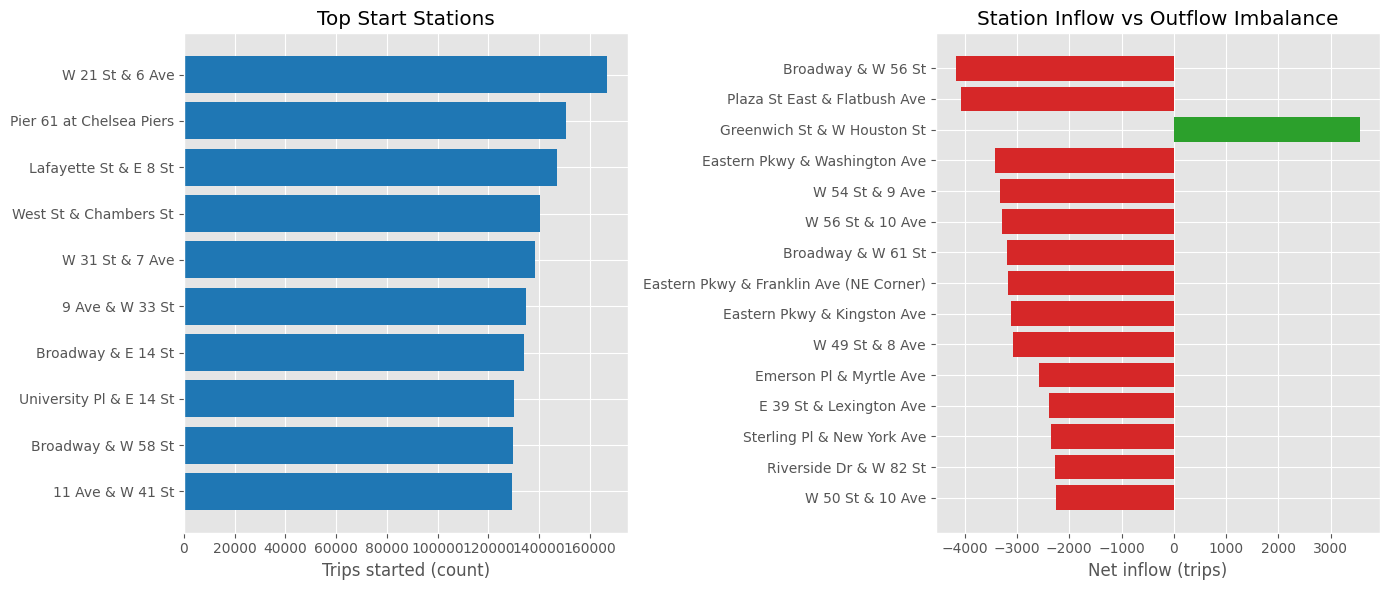

In [8]:
top_station_names = [row['station_name'] for row in reversed(top_start_stations_results)]
top_station_counts = [row['trip_count'] for row in reversed(top_start_stations_results)]
imbalance_station_names = [row['station_name'] for row in reversed(station_imbalance_results)]
net_inflow = [row['net_inflow'] for row in reversed(station_imbalance_results)]
colors = ['#2ca02c' if value >= 0 else '#d62728' for value in net_inflow]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_station_names, top_station_counts, color='#1f77b4')
axes[0].set_title('Top Start Stations')
axes[0].set_xlabel('Trips started (count)')

axes[1].barh(imbalance_station_names, net_inflow, color=colors)
axes[1].set_title('Station Inflow vs Outflow Imbalance')
axes[1].set_xlabel('Net inflow (trips)')

plt.tight_layout()
plt.show()


Ride starts are concentrated in a relatively small set of Manhattan hub stations such as W 21 St & 6 Ave, Pier 61 at Chelsea Piers, and Lafayette St & E 8 St. The imbalance chart is also more trustworthy after station-ID normalization, because formatting-only variants no longer split a single physical location across multiple rows.


## Section 6: User Behavior

This query compares member and casual riders on volume and trip duration. The full analytics SQL file also includes a default month-over-month `LAG` query for active-user change, and keeps the heavier gap-based churn proxy as an optional commented section rather than part of the default notebook path.


In [9]:
member_vs_casual_query = """
SELECT
    member_casual,
    COUNT(*) AS trip_count,
    ROUND(AVG(trip_duration_seconds) / 60.0, 2) AS avg_duration_minutes,
    ROUND(
        (
            PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY trip_duration_seconds) / 60.0
        )::numeric,
        2
    ) AS median_duration_minutes
FROM trips
WHERE member_casual IS NOT NULL
  AND trip_duration_seconds IS NOT NULL
  AND trip_duration_seconds > 0
  AND trip_duration_seconds < 86400
GROUP BY member_casual
ORDER BY trip_count DESC
"""

member_vs_casual_results = run_query(member_vs_casual_query)
member_vs_casual_results


[{'member_casual': 'member',
  'trip_count': 37778197,
  'avg_duration_minutes': Decimal('11.08'),
  'median_duration_minutes': Decimal('8.18')},
 {'member_casual': 'casual',
  'trip_count': 7983323,
  'avg_duration_minutes': Decimal('19.46'),
  'median_duration_minutes': Decimal('12.67')}]

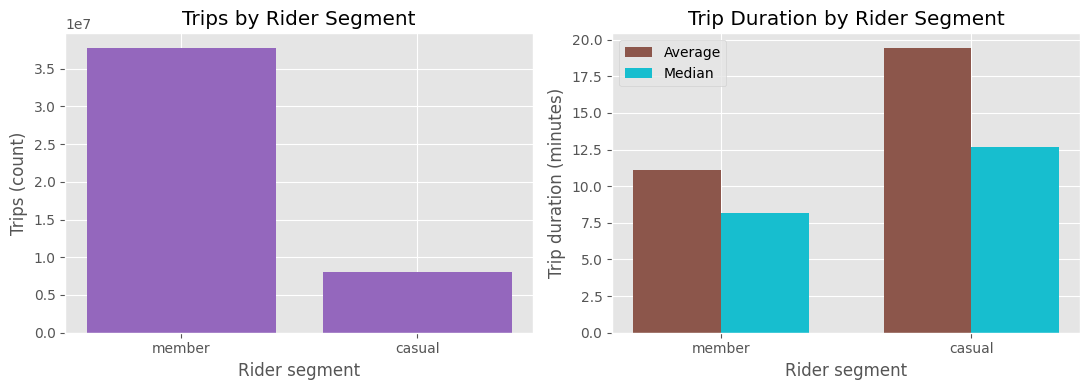

In [10]:
segments = [row['member_casual'] for row in member_vs_casual_results]
trip_counts = [row['trip_count'] for row in member_vs_casual_results]
avg_minutes = [row['avg_duration_minutes'] for row in member_vs_casual_results]
median_minutes = [row['median_duration_minutes'] for row in member_vs_casual_results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(segments, trip_counts, color='#9467bd')
axes[0].set_title('Trips by Rider Segment')
axes[0].set_xlabel('Rider segment')
axes[0].set_ylabel('Trips (count)')

x_positions = range(len(segments))
width = 0.35
axes[1].bar([x - width / 2 for x in x_positions], avg_minutes, width=width, label='Average', color='#8c564b')
axes[1].bar([x + width / 2 for x in x_positions], median_minutes, width=width, label='Median', color='#17becf')
axes[1].set_title('Trip Duration by Rider Segment')
axes[1].set_xlabel('Rider segment')
axes[1].set_ylabel('Trip duration (minutes)')
axes[1].set_xticks(list(x_positions))
axes[1].set_xticklabels(segments)
axes[1].legend()

plt.tight_layout()
plt.show()


Members account for most rides by a wide margin, while casual trips are materially longer on both average and median duration. On the rebuilt 2025 dataset, member volume is about 4.7 times larger, but casual rides last roughly 1.8 times as long on average, which supports the story of frequent utility trips versus longer discretionary usage.


## Section 7: Key Insights

- Demand is strongly seasonal, with the monthly active-user proxy rising from about 600 thousand in January to a late-summer peak of about 1.34 million in August.
- Month-over-month growth is strongest during the spring ramp and turns negative again as the system moves into late fall and early winter.
- Local-time hourly usage is strongest in the late afternoon and early evening, with 17:00 standing out as the busiest hour in the refreshed 2025 run.
- A relatively small group of Manhattan hub stations dominates ride starts, while imbalance is spread across several stations rather than driven by one runaway outlier.
- Members account for most trips, while casual riders take materially longer rides on both average and median duration.
- Rider-proxy metrics are useful for trend analysis, but they remain directional estimates rather than true rider-level counts because the public feed has no persistent user identifier.
